# Recovering sharp features with an L1-norm style inversion

By default, *Invert4Geom* solves each iteration of the inversion with a damped least-squares (L2-norm) solver.
L2-norm solutions penalize the *squared* size of the model corrections, which favors distributing corrections smoothly over many model cells.
This is a good choice for smoothly varying surfaces, but it smears out sharp features, such as the offset of a sedimentary basement surface across a fault.

To recover sharp (blocky) features, a common approach is to instead penalize an approximate L1 norm (or more generally an Lp norm with p < 2) of the *horizontal gradient* of the model, solved with **Iteratively Reweighted Least Squares (IRLS)** {cite:p}`farquharsonnonlinear1998,lastcompact1983`.
An L1-norm penalty on the model gradient (a *total variation* style regularization) favors models which are mostly flat, with the necessary changes concentrated into a few sharp steps, exactly the geometry of a faulted horizon.

This is available in *Invert4Geom* by passing `solver_type="irls"` to the [Inversion](../api/generated/invert4geom.Inversion.rst) class, along with:

- `sharpness_weight`: the trade-off parameter (often called $\beta$) between fitting the gravity data and penalizing model gradients. Higher values give blockier models at the expense of data fit.
- `sharpness_norm`: the norm $p$ used to penalize the model gradients, by default 1 (L1-norm / total variation). Values below 1 give even sharper models, while 2 reverts to a smooth L2-norm penalty.
- `irls_epsilon`: a small value stabilizing the reweighting for flat gradients, by default 0.1.

Each inversion iteration then solves the system

$$ \min_{\Delta m} \; \| J \Delta m - r \|_2^2 + \beta^2 \| W \, G \,(m + \Delta m) \|_2^2 $$

where $G$ is a first-difference operator over the model cells and $W$ is a diagonal matrix of IRLS weights, $W_{ii} = \left( (G m)_i^2 + \epsilon^2 \right)^{(p-2)/4}$, recalculated each iteration so that the quadratic penalty approximates $\sum_i |(Gm)_i|^p$.

In this notebook we:

1. create a synthetic model of a **basement surface offset by a fault**, overlain by lower-density sediment,
2. forward calculate its gravity anomaly and contaminate it with noise,
3. invert the gravity with the default smooth **L2-norm** solver,
4. invert it again with the new sharp **IRLS (L1-norm)** solver,
5. and compare how well each recovers the fault geometry.

## Import packages

In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import verde as vd

import invert4geom

## Create a synthetic faulted basement

We create a grid representing the depth to basement beneath a sedimentary basin.
A roughly north-south striking normal fault vertically offsets the basement by 600 m, with the downthrown (deeper) block to the west.
Rather than a perfectly straight trace, the fault zigzags between easting = 18 km and 22 km, so segments strike obliquely to the grid.
We also add some gentle, smooth undulations to both blocks so the surface isn't perfectly flat.

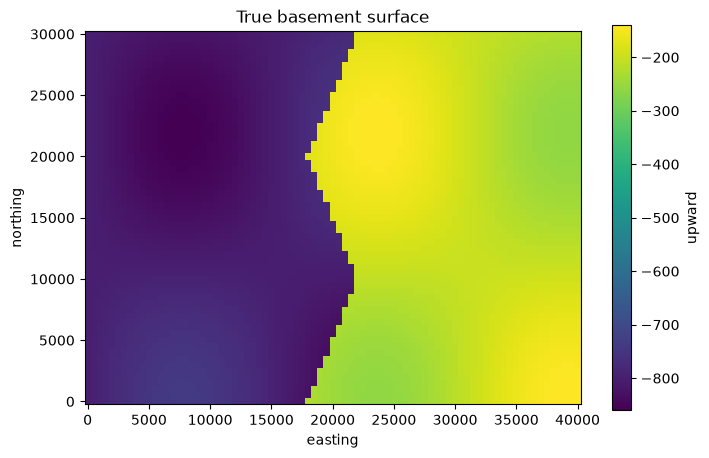

In [2]:
spacing = 500
region = (0, 40000, 0, 30000)

grid_coords = vd.grid_coordinates(spacing=spacing, region=region)
easting, northing = grid_coords

# zigzag fault trace: straight segments between these corner points
fault_knots_northing = [0, 10000, 20000, 30000]
fault_knots_easting = [18000, 22000, 18000, 22000]
fault_easting = np.interp(northing, fault_knots_northing, fault_knots_easting)

# 600 m vertical offset across the fault
basement = np.where(easting < fault_easting, -800.0, -200.0)

# add smooth undulations to both blocks
basement += 60 * np.sin(easting / 5e3) * np.cos(northing / 7e3)

true_topography = vd.make_xarray_grid(
    grid_coords,
    data=basement,
    data_names="upward",
).upward

true_topography.plot(figsize=(8, 5))
plt.gca().set_aspect("equal")
plt.title("True basement surface")
plt.show()

## Create the true model

The basement is overlain by less dense sediment, giving a density contrast across the basement surface of 400 kg/m$^3$.
We choose a reference level (`zref`) of -500 m, which is between the two basement levels, and use [create_model](../api/generated/invert4geom.create_model.rst) to discretize the surface into a layer of vertical prisms relative to that level: prisms above `zref` are assigned a positive density contrast and prisms below a negative one.

We can visualize this model in 3D with the [plot_model](../api/generated/invert4geom.DatasetAccessorInvert4Geom.plot_model.rst) accessor method, which uses [PyVista](https://docs.pyvista.org).
Making the prisms semi-transparent lets us see the fault scarp cutting through the model, with the two blocks either side of the reference level shown by their opposite density contrasts.

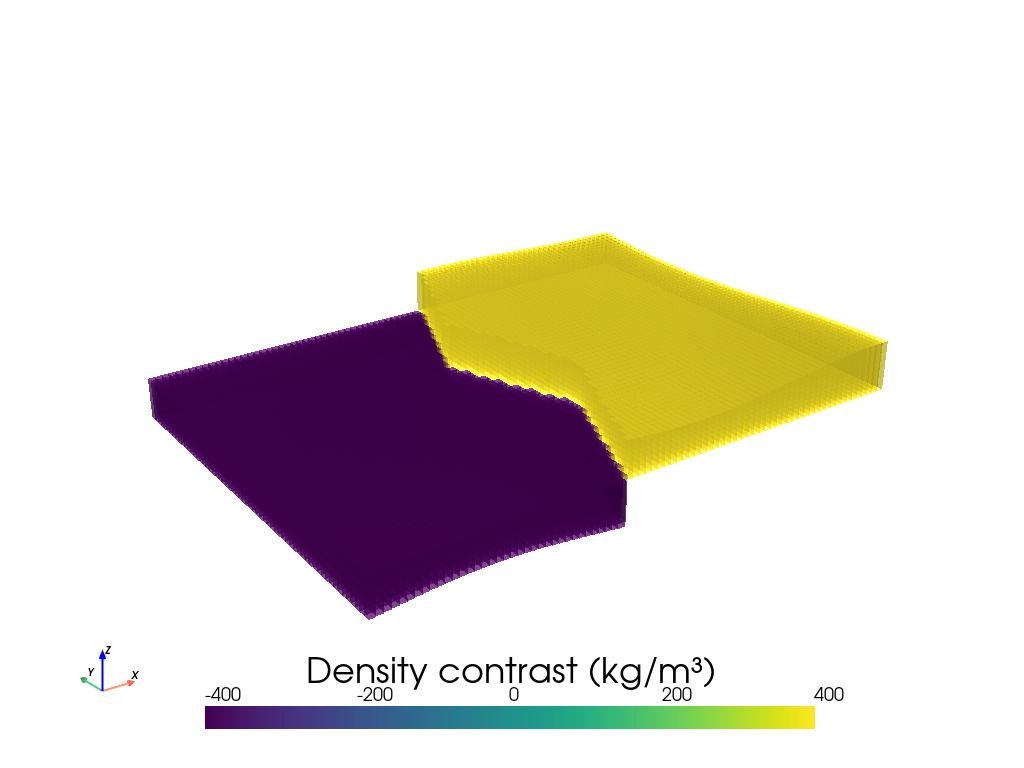

In [3]:
density_contrast = 400
zref = -500

true_model = invert4geom.create_model(
    zref=zref,
    density_contrast=density_contrast,
    topography=true_topography.to_dataset(),
)

# 3D view of the prism model, semi-transparent and vertically exaggerated
true_model.inv.plot_model(
    color_by="density",
    opacity=0.5,
    zscale=10,
    elevation=25,
    azimuth=-35,
)

## Forward calculate the observed gravity

Next we calculate the gravity effect of the true model at an observation height of 1000 m, and contaminate it with 0.1 mGal of Gaussian noise to use as our observed gravity.

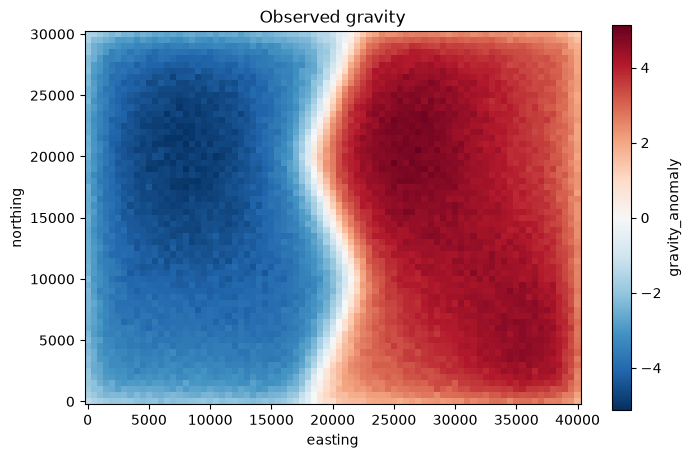

In [4]:
# gravity observation locations, 1000 m above sea level
observed_gravity = vd.make_xarray_grid(
    grid_coords,
    data=(np.zeros_like(easting), np.full_like(easting, 1000.0)),
    data_names=("gravity_anomaly", "upward"),
)

data = invert4geom.create_data(observed_gravity)

# forward gravity of the true model
data.inv.forward_gravity(true_model, progressbar=False)

# contaminate with 0.1 mGal of Gaussian noise and use as the observed gravity
# (keep the noise-free version so we can add other noise realizations later)
gravity_noise = 0.1
noise_free_gravity = data.forward_gravity.copy()
data["gravity_anomaly"], _ = invert4geom.synthetic.contaminate(
    noise_free_gravity,
    stddev=gravity_noise,
    seed=0,
)

data.gravity_anomaly.plot(figsize=(8, 5))
plt.gca().set_aspect("equal")
plt.title("Observed gravity")
plt.show()

## Create the starting model

As in the other tutorials, we assume we know nothing about the basement geometry and start with a flat surface at the reference level.
Since the starting model then has no gravity effect, and our synthetic gravity has no regional component, we set the regional field to a constant 0.

In [5]:
starting_topography = vd.make_xarray_grid(
    grid_coords,
    data=np.full_like(easting, zref),
    data_names="upward",
)

starting_model = invert4geom.create_model(
    zref=zref,
    density_contrast=density_contrast,
    topography=starting_topography,
)

data.inv.forward_gravity(starting_model, progressbar=False)
data.inv.regional_separation(method="constant", constant=0)
data

<xarray.Dataset> Size: 396kB
Dimensions:                   (northing: 61, easting: 81)
Coordinates:
  * northing                  (northing) float64 488B 0.0 500.0 ... 3e+04
  * easting                   (easting) float64 648B 0.0 500.0 ... 4e+04
Data variables:
    gravity_anomaly           (northing, easting) float64 40kB -1.332 ... 1.284
    upward                    (northing, easting) float64 40kB 1e+03 ... 1e+03
    forward_gravity           (northing, easting) float64 40kB -0.0 ... -0.0
    misfit                    (northing, easting) float64 40kB -1.332 ... 1.284
    reg                       (northing, easting) float64 40kB 0.0 0.0 ... 0.0
    res                       (northing, easting) float64 40kB -1.332 ... 1.284
    starting_forward_gravity  (northing, easting) float64 40kB -0.0 ... -0.0
    starting_misfit           (northing, easting) float64 40kB -1.332 ... 1.284
    starting_reg              (northing, easting) float64 40kB 0.0 0.0 ... 0.0
    starting_res              (northing, easting) float64 40kB -1.332 ... 1.284
Attributes:
    region:        (0.0, 40000.0, 0.0, 30000.0)
    spacing:       500.0
    buffer_width:  3000.0
    inner_region:  (3000.0, 37000.0, 3000.0, 27000.0)
    dataset_type:  data
    model_type:    prisms
    coord_names:   ('easting', 'northing')

## Smooth inversion (L2-norm)

First we run the inversion with the default `solver_type="scipy least squares"`, which finds the damped least-squares (L2-norm) solution each iteration.
We set the `l2_norm_tolerance` to $\sqrt{0.1} \approx 0.32$, since with 0.1 mGal of noise in the data we shouldn't try to fit the residual below the noise floor.
The damping value used here was chosen so that the inversion is able to fit the data down to that noise floor; ideally it would be chosen with a cross-validation, as shown in the [damping cross-validation tutorial](../tutorial/04_damping_cross_validation.ipynb).

In [6]:
inv_l2 = invert4geom.Inversion(
    copy.deepcopy(data),
    copy.deepcopy(starting_model),
    solver_damping=0.01,
    max_iterations=100,
    l2_norm_tolerance=np.sqrt(gravity_noise),
    delta_l2_norm_tolerance=1.0001,
)
inv_l2.invert(progressbar=True)
inv_l2.termination_reason

Iteration:   1%|1         | 1/100 [00:00<?, ?it/s]

['l2-norm tolerance']

## Sharp inversion (IRLS, L1-norm)

Now we run the same inversion with `solver_type="irls"` and a `sharpness_weight` of 0.01.
With the default `sharpness_norm=1`, this approximates an L1-norm (total variation) penalty on the horizontal gradient of the basement surface.

```{note}
As with the damping parameter, the optimal `sharpness_weight` is data-dependent: too high and the model will be too blocky to fit the data, too low and the result reverts towards the unregularized solution.
It should ideally be chosen with a cross-validation, as shown for the damping parameter in the [damping cross-validation tutorial](../tutorial/04_damping_cross_validation.ipynb).
A good starting point is a value which is small enough that the first iterations make clear progress in reducing the misfit.
```

In [7]:
inv_l1 = invert4geom.Inversion(
    copy.deepcopy(data),
    copy.deepcopy(starting_model),
    solver_type="irls",
    sharpness_weight=0.01,
    sharpness_norm=1,
    max_iterations=100,
    l2_norm_tolerance=np.sqrt(gravity_noise),
    delta_l2_norm_tolerance=1.0001,
)
inv_l1.invert(progressbar=True)
inv_l1.termination_reason

Iteration:   1%|1         | 1/100 [00:00<?, ?it/s]

['l2-norm tolerance']

## Compare the recovered basement surfaces

Both inversions fit the gravity data to a similar level, but they recover very different basement geometries.
Below we compare maps of the true and recovered basement surfaces, and the error of each.

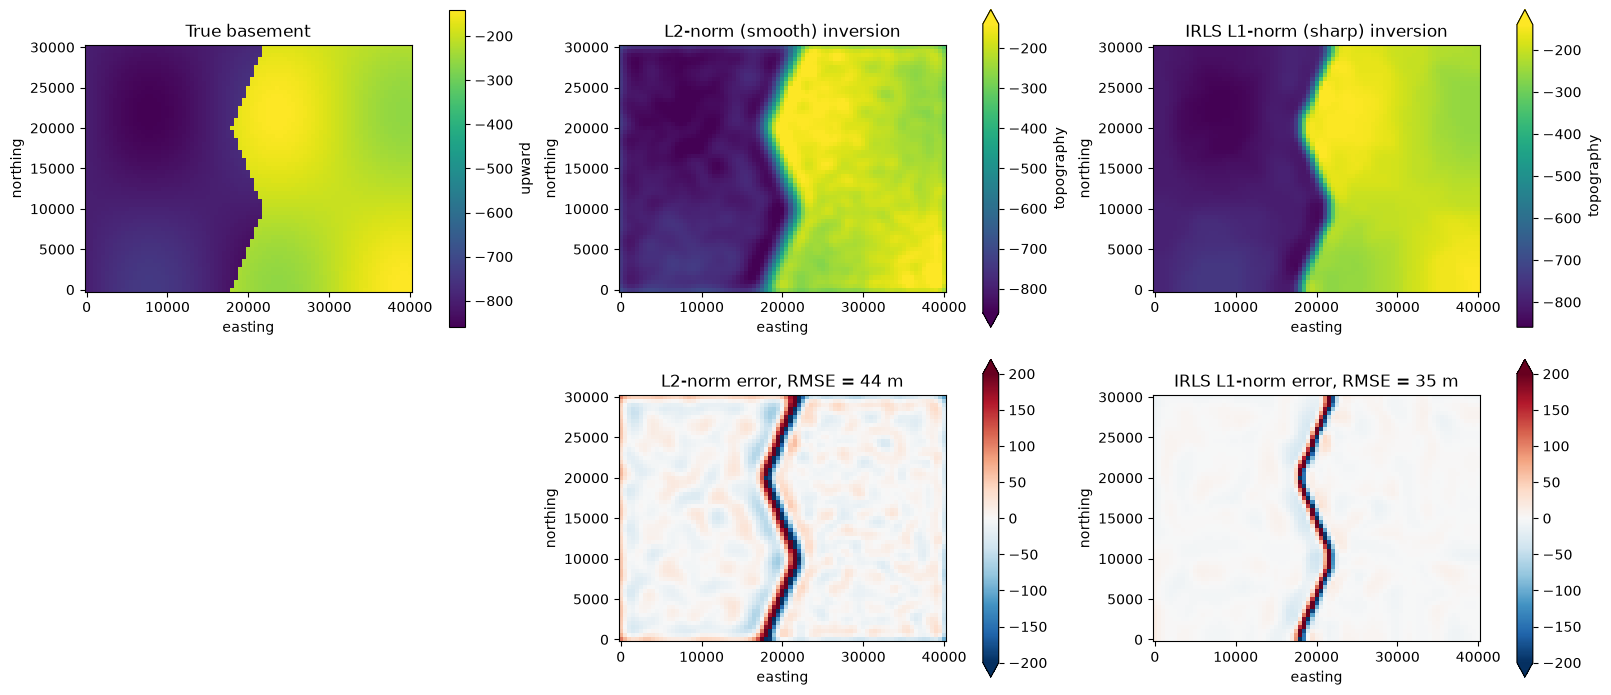

In [8]:
topo_l2 = inv_l2.model.topography
topo_l1 = inv_l1.model.topography

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

vmin, vmax = float(true_topography.min()), float(true_topography.max())

for ax, topo, title in zip(
    axes[0, :],
    [true_topography, topo_l2, topo_l1],
    ["True basement", "L2-norm (smooth) inversion", "IRLS L1-norm (sharp) inversion"],
    strict=True,
):
    topo.plot(ax=ax, vmin=vmin, vmax=vmax, cmap="viridis")
    ax.set_aspect("equal")
    ax.set_title(title)

axes[1, 0].axis("off")
for ax, topo, title in zip(
    axes[1, 1:],
    [topo_l2, topo_l1],
    ["L2-norm error", "IRLS L1-norm error"],
    strict=True,
):
    (topo - true_topography).plot(ax=ax, vmin=-200, vmax=200, cmap="RdBu_r")
    ax.set_aspect("equal")
    rmse = float(np.sqrt(np.mean((topo.values - true_topography.values) ** 2)))
    ax.set_title(f"{title}, RMSE = {rmse:.0f} m")
    ax.set_aspect("equal")

plt.show()

The difference is easiest to see on a west-east profile crossing the fault.
The L2-norm inversion smears the 600 m basement offset over several kilometers, while the IRLS inversion recovers a much sharper step at the correct location, with near-flat blocks on either side.

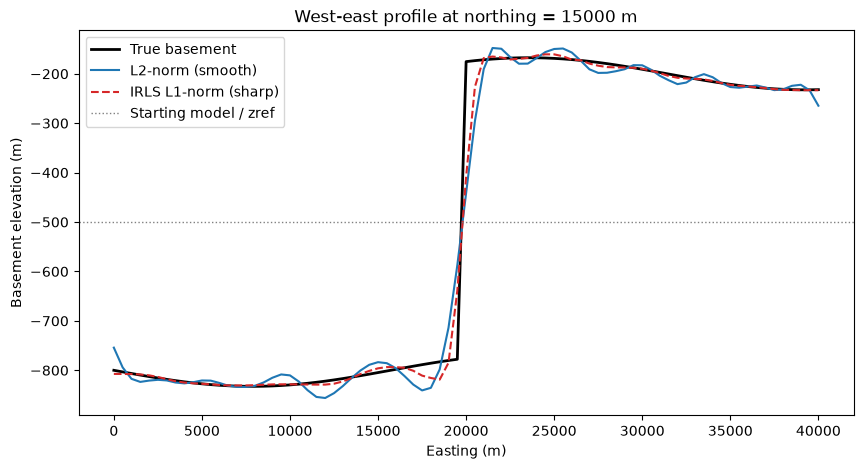

In [9]:
profile_northing = 15000

fig, ax = plt.subplots(figsize=(10, 5))

true_topography.sel(northing=profile_northing).plot(
    ax=ax, color="black", lw=2, label="True basement"
)
topo_l2.sel(northing=profile_northing).plot(
    ax=ax, color="tab:blue", lw=1.5, label="L2-norm (smooth)"
)
topo_l1.sel(northing=profile_northing).plot(
    ax=ax, color="tab:red", lw=1.5, ls="--", label="IRLS L1-norm (sharp)"
)
ax.axhline(zref, color="gray", ls=":", lw=1, label="Starting model / zref")

ax.set_title(f"West-east profile at northing = {profile_northing} m")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Basement elevation (m)")
ax.legend()
plt.show()

We can also check that the improved geometry doesn't come at the cost of a worse gravity fit by comparing the final residual gravity misfits.

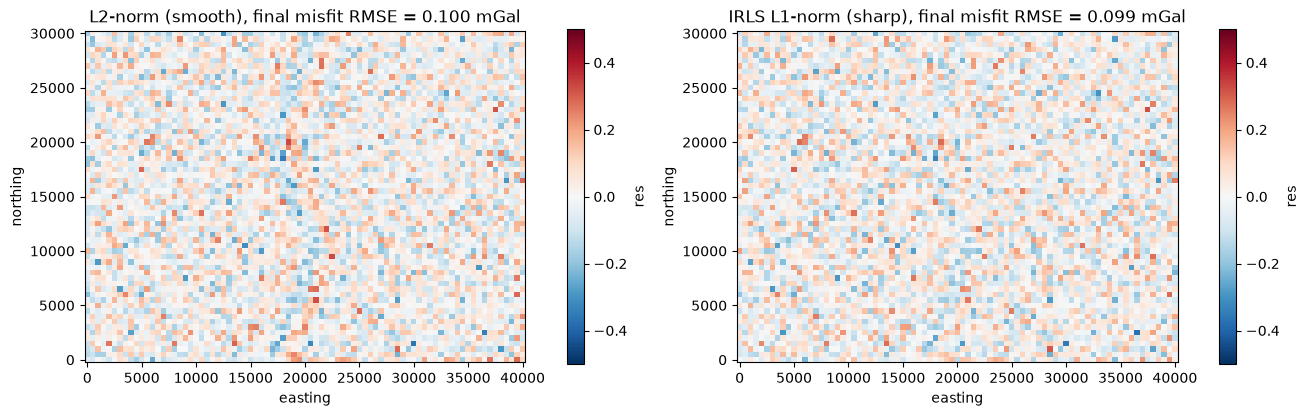

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

for ax, inv, title in zip(
    axes,
    [inv_l2, inv_l1],
    ["L2-norm (smooth)", "IRLS L1-norm (sharp)"],
    strict=True,
):
    inv.data.res.plot(ax=ax, vmin=-0.5, vmax=0.5, cmap="RdBu_r")
    ax.set_aspect("equal")
    ax.set_title(f"{title}, final misfit RMSE = {inv.rmse:.3f} mGal")

plt.show()

## Mapping the fault and its positional uncertainty

Recovering sharp gradients is most useful if we can use them to *locate* structures.
The function `invert4geom.uncertainty.topography_gradient_uncertainty` converts an **ensemble** of inverted topographies into fault-location statistics: for each ensemble member it computes the horizontal gradient magnitude of the topography, and the cell-wise fraction of members whose gradient exceeds a `threshold` gives a probability map of candidate fault scarps.
Cells where every member is steep are robust scarp positions, and the width of the high-probability band maps the horizontal uncertainty of the fault's position.

Here we build a small ensemble for each solver by repeating the inversion with different pseudo-random noise realizations of the observed gravity, and merge each set of recovered topographies with `invert4geom.uncertainty.merge_simulation_results`.

In [11]:
n_runs = 5


def inversion_ensemble(**kwargs):
    """repeat an inversion with different noise realizations of the observed gravity"""
    topographies = []
    for seed in range(n_runs):
        run_data = copy.deepcopy(data)
        run_data["gravity_anomaly"], _ = invert4geom.synthetic.contaminate(
            noise_free_gravity,
            stddev=gravity_noise,
            seed=seed,
        )
        run_data.inv.regional_separation(method="constant", constant=0)
        inv = invert4geom.Inversion(
            run_data,
            copy.deepcopy(starting_model),
            max_iterations=100,
            l2_norm_tolerance=np.sqrt(gravity_noise),
            delta_l2_norm_tolerance=1.0001,
            **kwargs,
        )
        inv.invert(progressbar=False)
        topographies.append(inv.model.topography)
    return invert4geom.uncertainty.merge_simulation_results(topographies)


ensemble_l2 = inversion_ensemble(solver_damping=0.01)
ensemble_l1 = inversion_ensemble(solver_type="irls", sharpness_weight=0.01)

Now we convert each ensemble into gradient statistics and a scarp probability map.
With a grid spacing of 500 m, the 600 m basement offset gives a gradient magnitude of up to 600 / (2 x 500) = 0.6 m/m at the fault (central differences spread a one-cell step over two cells), while the gentle background undulations are orders of magnitude flatter, so we count any cell steeper than 0.2 m/m as a candidate scarp.
The dashed line marks the true zigzag fault trace.

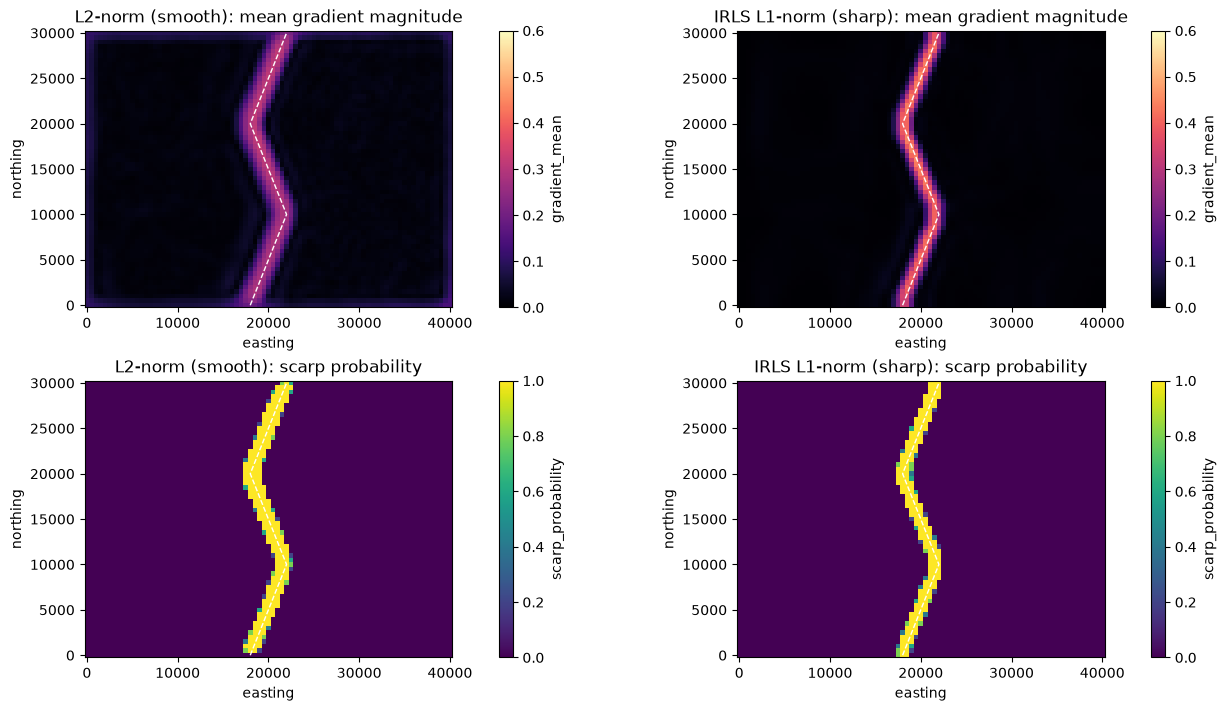

In [12]:
threshold = 0.2  # gradient magnitude (m/m) above which a cell counts as a scarp

grad_stats_l2 = invert4geom.uncertainty.topography_gradient_uncertainty(
    ensemble_l2, threshold=threshold
)
grad_stats_l1 = invert4geom.uncertainty.topography_gradient_uncertainty(
    ensemble_l1, threshold=threshold
)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)

for col, (stats, name) in enumerate(
    zip(
        [grad_stats_l2, grad_stats_l1],
        ["L2-norm (smooth)", "IRLS L1-norm (sharp)"],
        strict=True,
    )
):
    stats.gradient_mean.plot(ax=axes[0, col], vmin=0, vmax=0.6, cmap="magma")
    axes[0, col].set_title(f"{name}: mean gradient magnitude")
    stats.scarp_probability.plot(ax=axes[1, col], vmin=0, vmax=1, cmap="viridis")
    axes[1, col].set_title(f"{name}: scarp probability")
    for ax in axes[:, col]:
        ax.plot(fault_knots_easting, fault_knots_northing, color="white", ls="--", lw=1)
        ax.set_aspect("equal")

plt.show()

Both ensembles concentrate high scarp probability along the zigzag fault trace, including the segments oblique to the grid, but the IRLS ensemble is more decisive: its mean gradient at the fault approaches the theoretical maximum of 0.6 m/m and drops abruptly to near zero away from it, giving a tight probability band with sharp edges.
The L2 ensemble's peak gradient is only about half as strong and is smeared across a wider zone, so its probability band is broader — a larger horizontal uncertainty on the interpreted fault position — and its background gradients are visibly noisier, reflecting the oscillatory artifacts seen in the profile above.

## Final thoughts

Both inversions reduce the residual gravity misfit to the noise level, but only the IRLS (L1-norm style) inversion recovers the fault geometry: the sharp basement offset and the flat blocks on either side.
This illustrates the fundamental non-uniqueness of gravity inversion; the smooth and the sharp basement surfaces produce nearly identical gravity anomalies, so the choice of regularization is an *a priori* decision about what style of geology you expect.

Some practical guidance:

- Use `solver_type="irls"` when you expect discrete boundaries, such as faults, intrusion margins, or channel edges. Prefer the default smooth solver when the target surface is expected to vary gradually.
- Tune `sharpness_weight` (ideally with cross-validation) — it controls the trade-off between data fit and model blockiness.
- `sharpness_norm` can be reduced below 1 for even sharper results, or set to 2 to recover a smooth solution equivalent in style to the default solver.
- With noisy data, avoid setting `l2_norm_tolerance` below the noise floor, or the extra flexibility of any solver will be spent fitting noise.
- To interpret fault locations from an inversion, combine an ensemble of inversions (over noise realizations, or over uncertain parameters as in the [uncertainty analysis tutorial](../tutorial/10_uncertainty_analysis.ipynb)) with `invert4geom.uncertainty.topography_gradient_uncertainty` to obtain a scarp probability map, rather than relying on a single inverted surface.